# Exercise 3 — Hazard classification from exceedance probabilities

The dashboard for this exercise has **four threshold sliders**. Moving any of them
reclassifies a hazard map and recomputes an impact table. This notebook derives
both, so you can see what each threshold actually controls.

The question being answered is different from Exercise 2:

> **What are the odds of at least 30 cm of water here?**

Exercise 2 sampled *depth* from one specific storm. This works from
**exceedance probabilities** across an ensemble, which is a more useful product for
a forecast — but it means every number needs a threshold before it becomes a
decision, and that is where the difficulty lives.

**Workflow**

1. Look at the four probability rasters and what their values really are
2. Classify pixels into hazard levels with the escalating-gate rule
3. Discover a constraint in the data that limits what the top level can mean
4. Turn the classified raster into map polygons
5. Classify the buildings and roads directly, and verify how they were sampled
6. Build the impact table

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio.features import shapes

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
PROB = {                                    # EPSG:3857 copies, all on one grid
    "7p62": f"{BUCKET}/PBI_Actividad_2/prob_7p62.tif",
    "10cm": f"{BUCKET}/PBI_Actividad_2/prob_10cm.tif",
    "30cm": f"{BUCKET}/PBI_Actividad_2/prob_30cm.tif",
    "76cm": f"{BUCKET}/PBI_Actividad_2/prob_76cm.tif",
}
FEATURES = f"{BUCKET}/Guatemala_IBF/impact_features.csv"

print("ready")

ready


## 1. The four probability rasters

Each raster holds **P(flood depth ≥ threshold)** for one depth, produced from an
EF5 ensemble. A cell value of 0.3 in the 30 cm raster means *"in 30% of the
ensemble members, the water here reached at least 30 cm"*.

A common first confusion is worth clearing up now. If the 7.6 cm raster reads 0.5
and the 76 cm raster reads 0.2 in the same cell, that is not a contradiction — a
deeper flood is *rarer*, so probabilities fall as the threshold rises. The four
rasters are nested, not independent.

In [2]:
layers, meta = {}, {}
for name, url in PROB.items():
    with rasterio.open(url) as ds:
        layers[name] = ds.read(1, masked=True)
        meta[name] = {"crs": ds.crs, "shape": ds.shape,
                      "transform": ds.transform, "res": ds.res[0]}

for name, m in meta.items():
    print(f"prob_{name:<5} {m['crs']}  {m['shape']}  {m['res']:.0f} m")

shapes_seen = {v.shape for v in layers.values()}
print(f"\nall four share one grid: {len(shapes_seen) == 1}")

prob_7p62  EPSG:3857  (424, 319)  5 m
prob_10cm  EPSG:3857  (424, 319)  5 m
prob_30cm  EPSG:3857  (424, 319)  5 m
prob_76cm  EPSG:3857  (424, 319)  5 m

all four share one grid: True


### What the values actually are

Before classifying anything, look at the distinct values present. This is the
single most informative cell in the notebook.

In [3]:
for name, layer in layers.items():
    values = sorted(float(v) for v in np.unique(np.round(layer.compressed(), 3)))
    print(f"prob_{name:<5} {len(values):>2} distinct: "
          + ", ".join(f"{v:g}" for v in values))

prob_7p62  10 distinct: 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1
prob_10cm  10 distinct: 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1
prob_30cm  10 distinct: 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1
prob_76cm   2 distinct: 0, 0.2


Two findings, both of which change how you should read this product:

**1. The values are multiples of 0.1.** That is a **10-member ensemble** showing
through — each cell is *k*/10. So 0.35 is not a possible reading, and a continuous
colour ramp implies more precision than the data has. (Note `0.9` never occurs
while `1.0` does, which is a slightly odd tail.)

**2. The 76 cm raster contains only `{0, 0.2}`.** Nothing else. That is a hard
constraint: at most 2 of 10 members ever produced 76 cm anywhere in this domain.
Keep it in mind — it comes back in section 3 and it matters a lot.

> ⚠️ **The depth labels are wrong, upstream.** The filenames say 7.62 / 10 / 30 /
> 76 cm, but three of the four are actually **15.24 / 30.48 / 60.96 cm** (6, 12 and
> 24 inches). The *ordering* is correct either way, so the classification below is
> unaffected — but do not quote the centimetre figures as if they were verified.
> We kept the original names so they still match the filenames everyone else uses.

## 2. The classification rule

Each hazard level is tied to **one** depth layer, and each has its own probability
gate:

| level | driven by | notebook default gate |
|---|---|---|
| Bajo / Low | P(≥ 7.6 cm) | 0.3 |
| Medio / Medium | P(≥ 10 cm) | 0.2 |
| Alto / High | P(≥ 30 cm) | 0.1 |
| Severo / Severe | P(≥ 76 cm) | 0.15 |

A pixel takes the level of the **deepest** threshold whose gate it clears. That
falls out of assigning the levels in ascending order and letting later assignments
win — no explicit comparison needed.

This is a faithful port of `clasificar_peligro` from the UFFIS notebook.

In [4]:
LEVELS = [(1, "green"), (2, "yellow"), (3, "red"), (4, "purple")]
LEVEL_LABEL = {0: "Normal", 1: "Low", 2: "Medium", 3: "High", 4: "Severe"}
NODATA = 255
ORDER = ["7p62", "10cm", "30cm", "76cm"]      # shallowest to deepest


def clasificar_peligro(layers, gates):
    """0 = Normal, 1..4 = hazard level, 255 = NoData."""
    # A pixel missing from any layer cannot be classified at all.
    invalid = np.zeros(layers[ORDER[0]].shape, dtype=bool)
    for name in ORDER:
        invalid |= np.ma.getmaskarray(layers[name])

    hazard = np.zeros(layers[ORDER[0]].shape, dtype=np.uint8)
    # Ascending order: each assignment overwrites the last, so the deepest
    # threshold a pixel clears is the one that sticks.
    for name, (value, _colour) in zip(ORDER, LEVELS):
        hazard[layers[name].filled(-np.inf) >= gates[value]] = value

    hazard[invalid] = NODATA
    return hazard


GATES = {1: 0.3, 2: 0.2, 3: 0.1, 4: 0.15}       # the notebook defaults
hazard = clasificar_peligro(layers, GATES)

counts = pd.Series(
    {LEVEL_LABEL[v]: int((hazard == v).sum()) for v in [0, 1, 2, 3, 4]},
    name="pixels",
)
counts["NoData"] = int((hazard == NODATA).sum())
counts.to_frame()

,pixels
Normal,122026
Low,652
Medium,912
High,8855
Severe,2811
NoData,0


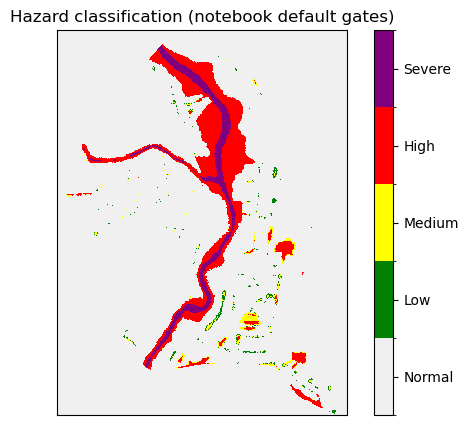

In [5]:
cmap = ListedColormap(["#f0f0f0", "green", "yellow", "red", "purple"])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(7, 5))
drawn = np.where(hazard == NODATA, np.nan, hazard)
im = ax.imshow(drawn, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title("Hazard classification (notebook default gates)")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels([LEVEL_LABEL[v] for v in [0, 1, 2, 3, 4]])
plt.show()

Note `interpolation="nearest"`. These are **class labels**, not a continuous
surface — averaging them would invent classes that do not exist and smear colour
across boundaries. The dashboard's categorical raster mode sets the equivalent
option for the same reason.

## 3. What the four gates actually mean — and a trap

Here is the difficulty with this design. "Severe" means *P(≥76 cm) ≥ 0.15* while
"High" means *P(≥30 cm) ≥ 0.1*. Those are two different questions with two
different cutoffs, so the levels are not comparable to each other, and the word
"severe" is doing no work on its own.

Try setting all four gates to the **same** value. Then every level means the same
thing — *"at least a p chance"* — and the label becomes the depth band, which is
self-explaining.

In [6]:
sweep = []
for p in [0.1, 0.2, 0.3, 0.5, 0.8]:
    uniform = clasificar_peligro(layers, {1: p, 2: p, 3: p, 4: p})
    sweep.append({"gate": p, **{LEVEL_LABEL[v]: int((uniform == v).sum())
                                for v in [1, 2, 3, 4]}})

pd.DataFrame(sweep).set_index("gate")

,Low,Medium,High,Severe
gate,,,,
0.1,2788,2044,8855,2811
0.2,2115,1906,7130,2811
0.3,1499,1094,4769,0
0.5,579,526,3952,0
0.8,276,417,2987,0


**Look at the Severe column.** Above a gate of 0.2 it is zero — not rare,
**impossible**. The 76 cm raster only ever contains 0 or 0.2, so no pixel can clear
a higher gate.

This is worth dwelling on in a workshop. Someone setting all four sliders to 0.8
because it sounds appropriately cautious will silently lose the top hazard class
entirely, and nothing on screen says so. The notebook's own default hides it by
accident: Severe's gate is 0.15, the only one of the four at or below 0.2.

Whenever you build a threshold control, check what range the underlying data can
actually reach.

## 4. From raster to map polygons

The dashboard draws this as a vector layer, not an image. There is no endpoint
serving a computed raster, so the classified grid is **vectorised**: each connected
run of equal class becomes one polygon carrying its class as an attribute.

Normal and NoData are left out. Normal is roughly 90% of the grid and adds nothing
a basemap does not already show, and dropping it keeps the payload small.

In [7]:
transform = meta["7p62"]["transform"]
mask = (hazard > 0) & (hazard != NODATA)

polygons = [
    {"geometry": geom, "hazard": int(value), "level": LEVEL_LABEL[int(value)]}
    for geom, value in shapes(hazard, mask=mask, transform=transform)
]
print(f"{len(polygons):,} polygons from {int(mask.sum()):,} classified pixels")

hazard_gdf = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "geometry": p["geometry"],
      "properties": {"hazard": p["hazard"], "level": p["level"]}} for p in polygons],
    crs=meta["7p62"]["crs"],
)
hazard_gdf.level.value_counts().to_frame("polygons")

585 polygons from 13,230 classified pixels


,polygons
level,
Low,272
Medium,253
High,41
Severe,19


Vectorising is exact, not an approximation — adjacent cells of equal class merge
into one polygon, so no detail is lost. About 600 polygons here, a few hundred KB
as GeoJSON.

## 5. Classifying the buildings and roads

Now the impact side. Each building and road in the IBF data **already carries the
four probabilities**, sampled onto it beforehand. So the same escalating gates
classify a feature directly — no rasterising involved.

In [8]:
features = pd.read_csv(FEATURES)
PROB_FIELDS = ["probability_7p62cm", "probability_10cm",
               "probability_30cm", "probability_76cm"]

print(f"{len(features):,} features")
print(features.tipo.value_counts().to_string())
print()
features[["tipo"] + PROB_FIELDS].head(3)

5,147 features
tipo
edificio     4689
carretera     458



,tipo,probability_7p62cm,probability_10cm,probability_30cm,probability_76cm
0,edificio,0.0,0.0,0.0,0.0
1,edificio,0.0,0.0,0.0,0.0
2,edificio,0.0,0.0,0.0,0.0


### How were those probabilities sampled?

This matters more than it looks. These four columns did **not** come from us — they
arrived already populated in the partners' geopackage
(`Guatemala_FF_event1_IBF3.gpkg`), with no note on how they were produced. If you
cannot say how a value got onto a building, you cannot defend it to anyone
relying on it, and you cannot recompute it for a new event.

So we reverse-engineer it. Several methods are plausible — the value at the
centroid, the maximum over the footprint, the minimum — and they give materially
different answers. Test each against the stored column and see which fits.

In [9]:
from rasterio.features import rasterize as rio_rasterize

# Test on the ORIGINAL UTM raster, not the EPSG:3857 copy used elsewhere in this
# notebook: the partners worked on the source grid. Section 5b shows what the
# reprojected copy costs.
NATIVE = f"{BUCKET}/Guatemala_IBF/guatemala_flood_30cm_probability_clipped.tif"
FIELD = "probability_30cm"

with rasterio.open(NATIVE) as ds:
    native_band = ds.read(1, masked=True).filled(0.0)
    native_shape, native_transform, native_crs = ds.shape, ds.transform, ds.crs

geo = gpd.read_file(f"{BUCKET}/Guatemala_IBF/impact_features.geojson").to_crs(native_crs)
stored = geo[FIELD].fillna(0.0).to_numpy()
n = len(geo)


def zonal(band, shape, transform, geometries, all_touched, reducer):
    """Per-feature reduction of band over each geometry's cells."""
    ids = rio_rasterize(
        ((g, i + 1) for i, g in enumerate(geometries)),
        out_shape=shape, transform=transform, fill=0,
        all_touched=all_touched, dtype="int32",
    )
    acc = np.full(n + 1, -np.inf if reducer is np.maximum else np.inf, "float32")
    reducer.at(acc, ids.ravel(), band.ravel())
    values = np.where(np.isfinite(acc[1:]), acc[1:], 0.0)
    covered = np.isin(np.arange(1, n + 1), np.unique(ids))
    return values, covered


trials = {
    "MAX, all_touched=True  (any cell the footprint touches)": (True, np.maximum),
    "MAX, all_touched=False (cells whose centre is inside)":   (False, np.maximum),
    "MIN, all_touched=True":                                   (True, np.minimum),
    "MIN, all_touched=False":                                  (False, np.minimum),
}

results = {}
for label, (all_touched, reducer) in trials.items():
    values, covered = zonal(native_band, native_shape, native_transform,
                            geo.geometry, all_touched, reducer)
    agree = np.isclose(values[covered], stored[covered], atol=1e-6)
    results[label] = (values, covered, agree)
    print(f"{100 * agree.mean():5.1f}%  of {covered.sum():>5,} in-domain  {label}")

 98.1%  of 5,033 in-domain  MAX, all_touched=True  (any cell the footprint touches)
 93.8%  of 4,810 in-domain  MAX, all_touched=False (cells whose centre is inside)


 88.6%  of 5,033 in-domain  MIN, all_touched=True
 89.1%  of 4,810 in-domain  MIN, all_touched=False


**The `all_touched` maximum is the clear winner at ~98%**, well ahead of the
centroid version (~94%) and the minimum (~89%). So the stored probability on each
feature is the worst case anywhere its footprint touches — the conservative
choice, and the same method Exercise 2 used for depth.

That is now a supported statement rather than an assumption, which is the point of
the exercise. But notice it is 98%, **not 100%**, and a method you have genuinely
recovered should reproduce every value. The remaining 2% is telling us
something, so look at it instead of rounding it away.

In [10]:
values, covered, agree = results[
    "MAX, all_touched=True  (any cell the footprint touches)"
]
delta = values[covered] - stored[covered]
missed = ~agree

print(f"{missed.sum()} features disagree, and almost all in one direction:")
print(f"   ours LOWER than stored:  {int((delta[missed] < 0).sum())}")
print(f"   ours HIGHER than stored: {int((delta[missed] > 0).sum())}")
print(f"   typical gap {np.abs(delta[missed]).mean():.2f}, "
      f"largest {np.abs(delta[missed]).max():.2f}")

kinds = geo.geometry[covered].geom_type.to_numpy()
print()
for kind in np.unique(kinds):
    share = 100 * missed[kinds == kind].mean()
    print(f"   {kind:<13} {share:4.1f}% disagree of {int((kinds == kind).sum()):,}")

96 features disagree, and almost all in one direction:
   ours LOWER than stored:  95
   ours HIGHER than stored: 1
   typical gap 0.16, largest 0.50

   LineString     3.6% disagree of 448
   MultiPolygon   1.7% disagree of 4,585


The disagreement is essentially **one-directional**: our value is lower than the
stored one, hardly ever higher. That rules out the boring explanations. Random
rounding or a tolerance problem would scatter both ways; a wrong reducer would be
wrong everywhere, not on 2% of features.

One-directional-low means the partners' sampling saw water that ours cannot
reach. The filename says it: every raster here is `..._clipped`. If the
probabilities were sampled *before* the rasters were clipped to this domain, then
features near the clip boundary keep a value from cells that no longer exist in
the file we have. We cannot confirm that without the pre-clip rasters — they are
not in the bucket — so it stays a hypothesis, but it is the one the evidence
points at, and it is the right question to send back to the data provider.

The practical takeaway for the workshop: **~98% with a one-directional residual is
a recovered method plus a known caveat, and that is an honest place to stop.**
Reporting it as "verified, matches exactly" would have hidden a real question
about the data.

### 5b. Why this used the *original* raster

The cell above reached for the `Guatemala_IBF` UTM file rather than the
`PBI_Actividad_2` copy the rest of the notebook uses. That was deliberate — run
the same best-fit method against the reprojected copy and the fit gets worse:

In [11]:
copy_values, copy_covered = zonal(
    layers["30cm"].filled(0.0), meta["30cm"]["shape"], transform,
    geo.to_crs(meta["30cm"]["crs"]).geometry, True, np.maximum,
)
copy_agree = np.isclose(copy_values[copy_covered], stored[copy_covered], atol=1e-6)

print(f"original {native_crs} grid at 4.825 m -> "
      f"{100 * agree.mean():.1f}% agreement")
print(f"copy     {meta['30cm']['crs']} grid at 5.000 m -> "
      f"{100 * copy_agree.mean():.1f}% agreement")

original EPSG:32615 grid at 4.825 m -> 98.1% agreement
copy     EPSG:3857 grid at 5.000 m -> 96.0% agreement


Two points of agreement lost purely to the regrid. The copy was resampled from
4.825 m to 5 m cells, so some buildings now touch a slightly different set of
cells and their maximum changes.

The copies are still the right choice for the dashboard — a UTM raster would drag
the whole map into UTM. But it is a real lesson worth carrying:
**zonal statistics are a property of the grid, not only of the geometry.** To
reproduce someone else's sampled values, sample on their grid.

In [12]:
def classify_features(df, gates):
    hazard = pd.Series(0, index=df.index, dtype="uint8")
    for field, (value, _colour) in zip(PROB_FIELDS, LEVELS):
        hazard[df[field] >= gates[value]] = value      # deepest gate cleared wins
    return hazard


features["hazard"] = classify_features(features, GATES)
features["level"] = features.hazard.map(LEVEL_LABEL)
features.level.value_counts().to_frame("features")

,features
level,
Normal,3930
High,790
Low,168
Medium,167
Severe,92


## 6. The impact table

This is what the dashboard shows. Deepest level first; Normal is left out because
it is everything the gates did not catch, so it carries no exposure.

In [13]:
TOTAL_POPULATION = 290_868          # every building in the geopackage


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Level": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.poblacion.sum():,.0f}",
        "Area (m²)": f"{group.area_m2.sum():,.0f}",
        "Roads (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


at_risk = features[features.hazard > 0]
table = [impact_row(LEVEL_LABEL[v], at_risk[at_risk.hazard == v])
         for v, _c in reversed(LEVELS)]
table.append(impact_row("TOTAL at risk", at_risk))

pd.DataFrame(table).set_index("Level")

,Buildings,Population,Area (m²),Roads (km),% of population
Level,,,,,
Severe,80,160,"4,939",1.0,0.05%
High,677,"1,888","60,921",10.3,0.65%
Medium,123,441,"15,538",3.4,0.15%
Low,131,401,"13,214",3.2,0.14%
TOTAL at risk,"1,011","2,891","94,612",17.9,0.99%


A rounding note you will see if you add up the Population column: the four
level rows sum to one less than the total. Both are the same underlying figure —
`poblacion` is a disaggregated estimate, so it holds fractional people, and four
values each rounded to the nearest integer need not sum to the rounded total.

## 7. Mapping it

Hazard polygons underneath, affected buildings and roads on top — the same two
layers the dashboard stacks.

/tmp/ipykernel_2044603/1016584565.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


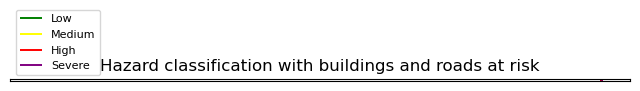

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
for value, colour in LEVELS:
    subset = hazard_gdf[hazard_gdf.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, alpha=0.55, linewidth=0)

geo["hazard"] = classify_features(
    geo.assign(**{f: geo[f].fillna(0.0) for f in PROB_FIELDS}), GATES
)
for value, colour in LEVELS:
    subset = geo[geo.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.4,
                    edgecolor=colour, label=LEVEL_LABEL[value])

ax.set_title("Hazard classification with buildings and roads at risk")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 8. How the dashboard plugins do it

Three plugins share the core rule from section 2:

| plugin | type | what it returns |
|---|---|---|
| `wmo_impact_summary_en` / `_es` | `table` | the table from section 6 |
| `wmo_hazard_layer_en` / `_es` | `map_layer` | the polygons from section 4 |
| `wmo_impact_layer_en` / `_es` | `map_layer` | the features from section 5 |

Implementation notes worth knowing:

- **The gates are keyed by class value, not by name.** `gates[1]` rather than
  `gates["Bajo"]`. That is what lets one implementation serve both the English and
  Spanish plugins: a translation cannot change a classification.
- **Both map layers are `dynamic_map_layer`s** — they re-run `fetch_features()`
  whenever a bound threshold changes, which is what makes the sliders interactive.
- **The table reads a slim CSV, not the geopackage.** The original is 37.7 MB and
  takes about 160 s to read over the network; unusable from a dashboard. Only the
  columns needed were precomputed, exactly as in Exercise 2.
- **The feature layer outputs EPSG:4326.** The source data is UTM 15N, and the
  frontend does not bundle proj4, so OpenLayers could not place it. Reprojecting in
  the plugin avoids that.
- **The rasters are the `PBI_Actividad_2` EPSG:3857 copies**, not the
  `Guatemala_IBF` originals, which are UTM. A UTM raster makes the map adopt that
  projection, which costs a reprojection on every tile.

Run the cell below to read the real classification code, if the package is
installed.

In [15]:
import inspect

try:
    from tgf_wmo_plugins import classification
    print(inspect.getsource(classification.clasificar_peligro))
except ImportError:
    print("tgf_wmo_plugins is not installed here.\n"
          "Install it with:  pip install -e .   from the repository root.")

def clasificar_peligro(prob7p62, prob10cm, prob30cm, prob76cm, umbrales_peligro):
    """Classify flood hazard from the four probability layers.

    4 = Severo, 3 = Alto, 2 = Medio, 1 = Bajo, 0 = Normal, 255 = NoData.
    """
    # A pixel missing from any layer cannot be classified.
    invalid = (
        np.ma.getmaskarray(prob7p62)
        | np.ma.getmaskarray(prob10cm)
        | np.ma.getmaskarray(prob30cm)
        | np.ma.getmaskarray(prob76cm)
    )

    peligro = np.zeros(prob7p62.shape, dtype=np.uint8)

    # Ascending order: each assignment overwrites the last, so the deepest
    # threshold that clears its gate is the one that sticks.
    layers = (prob7p62, prob10cm, prob30cm, prob76cm)
    # Gates arrive keyed by level value, not by name, so the classification is
    # identical in both languages.
    for layer, (value, _color) in zip(layers, LEVELS):
        peligro[layer.filled(-np.inf) >= umbrales_peligro[value]] = value

    peligro[invalid] = NODATA
    return peligr

### Things to try

- Set all four gates equal in section 3 and re-run sections 5–7. Does the map
  become easier to explain?
- Push the Severe gate above 0.2 and confirm the class disappears from both the
  table and the map. How would you stop a dashboard user doing this by accident?
- Section 5 recovered the sampling method for `probability_30cm` and hit ~98%. Run
  the same four trials on the other three fields. Does `all_touched` MAX stay the
  best fit, and is the residual one-directional there too? If the clip hypothesis
  is right, the shallowest layer should be the worst affected — it has the largest
  wet footprint, so the most features near the boundary.
- Exercise 2 answered "how deep in storm 150", this one "what are the odds of 30 cm".
  Both use the same buildings on the same grid. Which would you put in front of a
  civil-protection officer, and what would you say about the other?